<a href="https://colab.research.google.com/github/rainforest01-coder/ESAA_files/blob/OB/%ED%86%B5%EC%9D%B8%EC%A7%80_%EA%B3%BC%EC%A0%9C1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
data

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Sun Jun 12 21:49:41 2016',
 '__version__': '1.0',
 '__globals__': [],
 'word': array([[array([['h', 'o', 'l', 'e', 's']], dtype='<U1')],
        [array([['m', 'u', 's', 't']], dtype='<U1')],
        [array([['t', 'o', 'p', '_', 's', 'e', 'c', 'r', 'e', 't']], dtype='<U1')],
        ...,
        [array([['t', 'h', 'e', 'a', 't', 'e', 'r']], dtype='<U1')],
        [array([['h', 'e', 'n', 'c', 'e', '_', 't', 'h', 'e']], dtype='<U1')],
        [array([['s', 'e', 'e', 'm', 'e', 'd', '_', 'l', 'i', 'k', 'e']],
               dtype='<U1')                                              ]],
       dtype=object),
 'sentiment': array([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
 

In [ ]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


data = sio.loadmat('./sentimentdataset.mat', chars_as_strings=1, matlab_compatible=1)

bagofword = data['bagofword']
sentiment = data['sentiment']
sentiment = sentiment.astype(int)
words = data['word']

# join character to word
# ex.) [['h', 'o', 'l', 'e', 's']]  -> "holes"
word = []
for n in range(20):
    word = word + [str(''.join(letter)) for letter in words[n][0]]
print(word)


numDoc = len(bagofword) # number of documents
numTesting = 50 # number of testing documents
numVoca = len(words) # number of vocabs, use small number (ex. 1000) for debugging
step = (numDoc-numTesting)//10 # number of steps of increment of training documents
repeat = 5 # number of repetitions of the experiment, use small number (ex. 2) for debugging
alpha = 1. # Beta distribution parameter, initially set as 1, i.e., no prior assumption
beta = 1. # Beta distribution parameter, initially set as 1, i.e., no prior assumption
delta = 1e-12 # small amount for preventing log 0

trainingAccuracy = np.zeros((repeat,step))
testingAccuracy = np.zeros((repeat,step))
avgTraining = np.zeros((step,1))
stdTraining = np.zeros((step,1))
avgTesting = np.zeros((step,1))
stdTesting = np.zeros((step,1))


['holes', 'must', 'top_secret', 'he', 'center', 'other_civilans', 'the_pacific', 'the_navy', 'a_lot', 'surface_must', 'this_book', 'man_named', '<num>_feet', 'would_strongly', 'put_down', 'norman_johnson', 'lawes', 'a_top', 'the_support', 'ten']


In [ ]:
bagofword[0]

array([1., 1., 1., ..., 0., 0., 0.])

In [ ]:
sample = np.random.permutation(np.arange(numDoc))
sample

array([187,  31, 143,  98, 115,  85, 164, 152, 148, 104,  93,  83,  74,
        51,  20, 110,  61, 103,  24,  99,  56,  43, 131,  27, 140,  79,
        32,  66,  17,  33, 137,  68,  13, 156,  67, 120,  41, 133,   8,
       193,  22,  45,  37, 127, 181, 180, 178,  48, 172, 106, 189,  15,
       174, 117,  42, 173, 175, 186,  35,  52,  76, 170,   2, 142, 153,
       165, 168, 135,  39,  14, 108,  38,  72, 114,   9,  87, 179,  62,
        65,  26,  19, 147, 183,  57, 192,  90,  94,  58,  64,  80,  36,
       107,   4,  91,  49, 129, 146, 145,  54,  10, 138, 100,   7,  53,
       126, 176, 130,  81,  86, 109, 185,  89, 195, 124, 159, 158,   3,
        29,  23,  97, 167,  60,  40, 121,  70,  30, 197,  21, 144,   0,
       191,   6, 125,  34, 113, 151, 190,  92, 163, 155,  78,  82, 112,
       136,   5,  44, 116,  16, 132, 141,  12, 188,  46, 162, 166, 119,
       101,  84, 177,  47,  25,   1, 134,  59, 196, 105,  88,  28, 102,
        77, 194, 154, 160, 182,  96,  50, 118,  73,  63,  11, 16

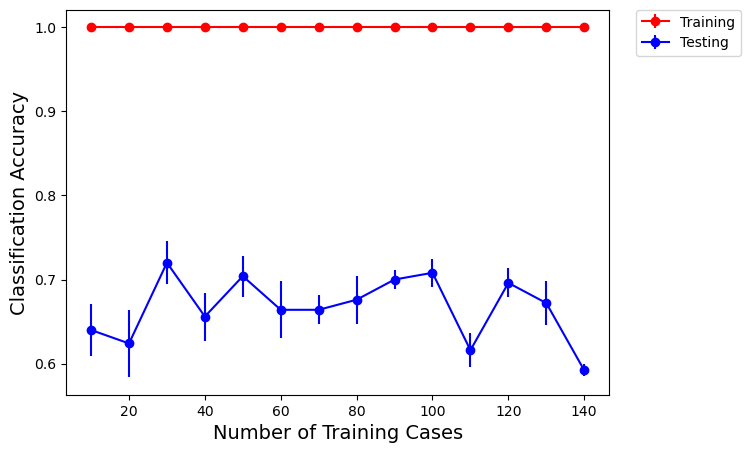

In [ ]:

for M in range(1,step+1): # iteration over the size of training documents
    N = M * 10; # the size of actual training documents
    for rep in range(repeat):
        sample = np.random.permutation(np.arange(numDoc))

        #### HERE ####
        # give permutation to the dataset
        X =bagofword[sample]
        Y = sentiment[sample]
        ## fill out X,Y ##
        X_train=X[:N]
        y_train=Y[:N]

        X_test=X[N:N+numTesting]
        y_test=Y[N:N+numTesting]

        #### HERE ####
        # count the occurrence of Y
        cntY = np.zeros((2,1))
        ## fill out cntY ##
        cntY[1,0]=np.sum(y_train) ##positive 문서 개수
        cntY[0,0]=len(y_train)-np.sum(y_train) ##negative 문서 개수

        #### HERE ####
        # count the occurrence of (X,Y)
        cntXbyY = np.zeros((numVoca,2))
        ## fill out cntXbyY ##
        cntXbyY[:,0]=np.sum(X_train[y_train.flatten()==0],axis=0)
        cntXbyY[:,1]=np.sum(X_train[y_train.flatten()==1],axis=0)

        #### HERE ####
        # compute the probability of Y
        probsY = np.zeros((2,1))
        ## fill out probsY ##
        probsY[0,0]=cntY[0,0]/len(y_train)
        probsY[1,0]=cntY[1,0]/len(y_train)

        #### HERE ####
        # compute the probability of (X|Y)
        probsXbyY = np.zeros((numVoca, 2))
        ## fill out probsXbyY ##
        probsXbyY=(cntXbyY+alpha)/(np.sum(cntXbyY,axis=0,keepdims=True)+alpha*numVoca)

        #### HERE ####
        # compute log probability of positive/negative sentiment for all docs
        logProbsSentiment = np.zeros((numDoc,2))
        ## fill out logProbsSentiment ##
        logProbsSentiment=X@np.log(probsXbyY)+np.log(probsY).T

        #### HERE ####
        # predict sentiment of documents
        estSentiment = np.zeros((numDoc,1))
        ## fill out estSentiment ##
        #estSentiment = np.argmax(logProbsSentiment,axis=1).reshape(numDoc,1) 지피티
        for i in range(0,numDoc):
            if logProbsSentiment[i,1]>logProbsSentiment[i,0]:
                estSentiment[i]=1



        #### HERE ####
        # compute accuracy for training set
        cntCorrect = np.sum(estSentiment[:N]==y_train)
        ## fill out cntCorrect ##
        trainingAccuracy[rep,M-1] = cntCorrect / float(N)

        #### HERE ####
        # compute accuracy for testing set
        cntCorrect = np.sum(estSentiment[N:N+numTesting]==y_test)
        ## fill out cntCorrect ##
        testingAccuracy[rep,M-1] = cntCorrect / float(numTesting)


    #### HERE ####
    ## fill out the following ##
    # compute average of accuracies
    avgTraining[M-1] = np.mean(trainingAccuracy[:,M-1])
    avgTesting[M-1] = np.mean(testingAccuracy[:,M-1])
    # compute standard deviation of accuracies
    stdTraining[M-1] = np.std(trainingAccuracy[:,M-1])
    stdTesting[M-1] = np.std(testingAccuracy[:,M-1])


plt.figure(1,figsize=(7,5))
plt.errorbar(np.dot(10,range(1,step+1)),avgTraining.squeeze(),yerr=stdTraining.squeeze()/np.sqrt(repeat),fmt='-o',color='r',label="Training")
plt.errorbar(np.dot(10,range(1,step+1)),avgTesting.squeeze(),yerr=stdTesting.squeeze()/np.sqrt(repeat), fmt='-o',color='b',label="Testing")

plt.legend(bbox_to_anchor=(1.05,1),loc=2,borderaxespad=0.)
plt.xlabel('Number of Training Cases',fontsize=14)
plt.ylabel('Classification Accuracy',fontsize=14)

plt.show()

In [ ]:
trainingAccuracy

array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])